In [8]:
import anndata
import networkx as nx
import numpy as np
import scgenome.plotting as pl

from cellmates.utils.tree_utils import f1_score_clades, relabel_name_to_int, newick_to_nx, convert_networkx_to_dendropy, \
    nxtree_to_newick, normalized_rf_distance

# Real datasets

## SA501X3F

In [31]:
path = "/home/vittorio.zampinetti/data/SA501X3F.h5ad"

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 260 × 18175
    var: 'chr', 'start', 'end'
    layers: 'copy'

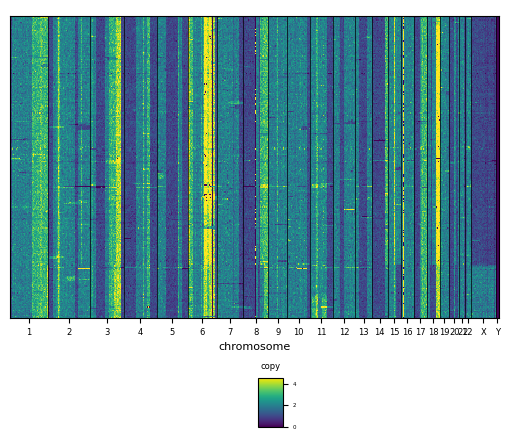

In [32]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', raw=True, vmax=perc_98)

### VICTree out CN

In [33]:
adata = anndata.read_h5ad("/home/vittorio.zampinetti/data/SA501X3F_vic.out.h5ad")
adata

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 260 × 18175
    obs: 'victree-mu', 'victree-mt-lambda', 'victree-mt-alpha', 'victree-mt-beta', 'victree-tau', 'victree-clone', 'victree-loglik', 'victree-elbo-terms'
    var: 'index', 'chr', 'start', 'end'
    uns: 'victree-elbo', 'victree-elbo-history', 'victree-eps-alpha', 'victree-eps-beta', 'victree-log-likelihood', 'victree-pruned-clusters', 'victree-pruned-elbo', 'victree-tree-graph', 'victree-tree-newick', 'victree-tree-newick-pruned', 'victree-tree-probs', 'victree-tree-probs-pruned'
    obsm: 'victree-clone-probs'
    varm: 'victree-cn-pprobs', 'victree-cn-sprobs'
    layers: 'victree-cn-marginal', 'victree-cn-viterbi'

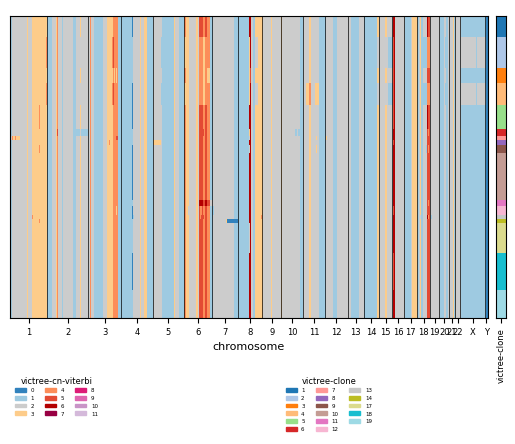

In [34]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='victree-cn-viterbi', cell_order_fields=['victree-clone'], annotation_fields=['victree-clone'])

## S0_10x data


In [35]:
path = "/home/vittorio.zampinetti/data/s0_10x_500kb.h5ad"
# /home/vittorio.zampinetti/data/signals_SPECTRUM-OV-006.h5
# /home/vittorio.zampinetti/data/signals_SPECTRUM-OV-014.h5
# /home/vittorio.zampinetti/data/signals_SPECTRUM-OV-107.h5
# /home/vittorio.zampinetti/data/SA501X3F.h5ad

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 10088 × 6082
    obs: 'region', 'normal'
    var: 'chr', 'start', 'end'
    layers: 'Acount', 'Bcount'

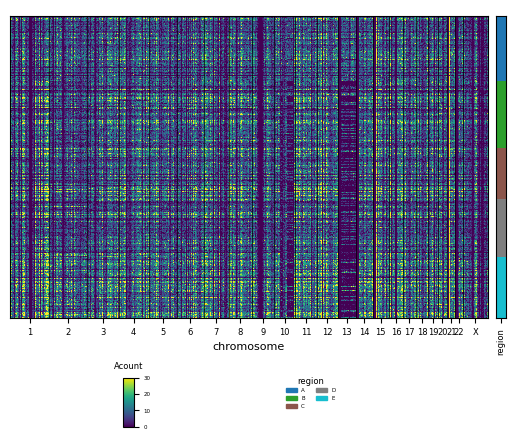

In [36]:
perc_98 = np.nanquantile(adata.layers['Acount'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='Acount', cell_order_fields=['region'], annotation_fields=['region'], raw=True, vmax=perc_98)

### 5Mb version with CN and clones

In [37]:
adata = anndata.read_h5ad("/home/vittorio.zampinetti/victree-extended/experiments/chisel_compare/results/victree_out/victree.out.h5ad")
adata


AnnData object with n_obs × n_vars = 9279 × 620
    obs: 'region', 'normal', 'baseline_chisel', 'victree-mu', 'victree-mt-lambda', 'victree-mt-alpha', 'victree-mt-beta', 'victree-tau', 'victree-clone', 'victree-loglik'
    var: 'chr', 'start', 'end'
    uns: 'victree-elbo', 'victree-elbo-history', 'victree-elbo-term-c', 'victree-elbo-term-eps', 'victree-elbo-term-mt', 'victree-elbo-term-obs', 'victree-elbo-term-pi', 'victree-elbo-term-t', 'victree-elbo-term-xi', 'victree-elbo-term-z', 'victree-eps-alpha', 'victree-eps-beta', 'victree-exec-time', 'victree-iters', 'victree-log-likelihood', 'victree-max-iter', 'victree-pruned-clusters', 'victree-pruned-elbo', 'victree-tree-graph', 'victree-tree-mst', 'victree-tree-newick', 'victree-tree-newick-pruned', 'victree-tree-probs', 'victree-tree-probs-pruned', 'victree-xi-a', 'victree-xi-b'
    obsm: 'victree-clone-probs'
    varm: 'victree-cn-pprobs', 'victree-cn-pprobs-A', 'victree-cn-pprobs-B', 'victree-cn-sprobs', 'victree-cn-sprobs-A', 'vict

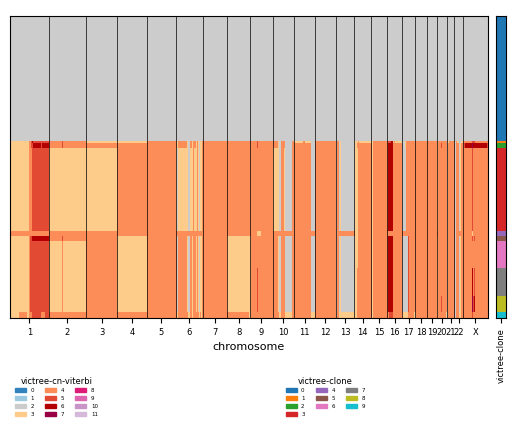

In [38]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='victree-cn-viterbi', cell_order_fields=['victree-clone'], annotation_fields=['victree-clone'])

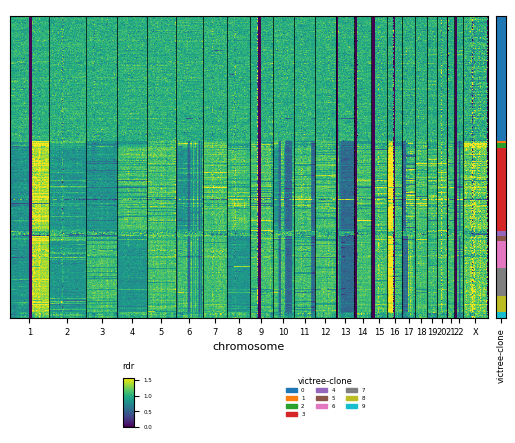

In [39]:
perc_99 = np.nanquantile(adata.layers['rdr'], .99)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='rdr', cell_order_fields=['victree-clone'], annotation_fields=['victree-clone'], raw=True, vmax=perc_99)

## bahlis_10x MM03

In [9]:
path = "/home/vittorio.zampinetti/data/patient_MM-03.h5ad"

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 2208 × 5298
    obs: 'cell_id', 'effective_depth_of_coverage', 'effective_reads_per_1Mbp', 'est_cnv_resolution_mb', 'frac_mapped_duplicates', 'is_high_dimapd', 'is_noisy', 'mean_ploidy', 'normalized_dimapd', 'normalized_mapd', 'num_duplicate_reads', 'num_lowmapq_reads', 'num_mapped_dedup_reads', 'num_unmapped_reads', 'ploidy_confidence', 'raw_dimapd', 'raw_mapd', 'total_num_reads', 'state_mean', 'state_var', 'is_normal', 'patient_id', 'dataset', 'description', 'cluster_id', 'cluster_size', 'cell_order'
    var: 'chr', 'start', 'end', 'gc_fraction', 'cyto_band_name', 'cyto_band_giemsa_stain'
    uns: 'clustering'
    layers: 'copy', 'normalized_counts', 'state'

In [10]:
#manipulate chr
chr_codes = {c: c[3:] for c in adata.var['chr'].unique()}
adata.var['chr'] = adata.var['chr'].map(chr_codes)

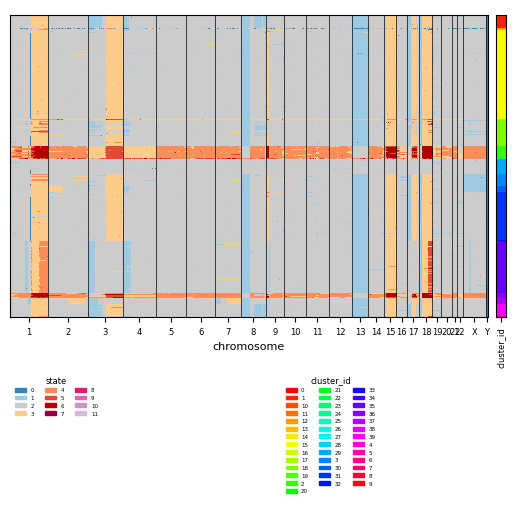

In [11]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

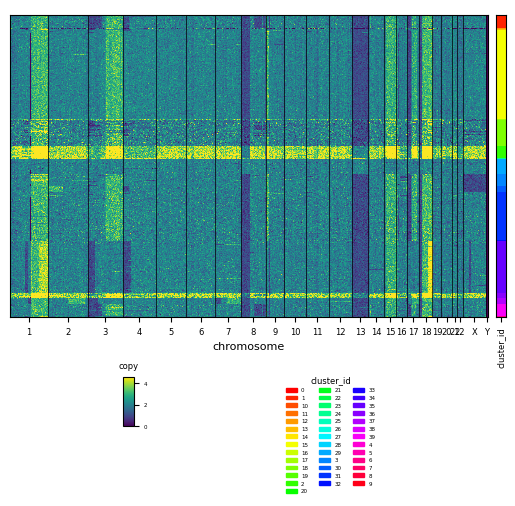

In [12]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

### Zoom on WGD cells

In [13]:
adata[adata.obs['mean_ploidy'] > 3]

View of AnnData object with n_obs × n_vars = 138 × 5298
    obs: 'cell_id', 'effective_depth_of_coverage', 'effective_reads_per_1Mbp', 'est_cnv_resolution_mb', 'frac_mapped_duplicates', 'is_high_dimapd', 'is_noisy', 'mean_ploidy', 'normalized_dimapd', 'normalized_mapd', 'num_duplicate_reads', 'num_lowmapq_reads', 'num_mapped_dedup_reads', 'num_unmapped_reads', 'ploidy_confidence', 'raw_dimapd', 'raw_mapd', 'total_num_reads', 'state_mean', 'state_var', 'is_normal', 'patient_id', 'dataset', 'description', 'cluster_id', 'cluster_size', 'cell_order'
    var: 'chr', 'start', 'end', 'gc_fraction', 'cyto_band_name', 'cyto_band_giemsa_stain'
    uns: 'clustering'
    layers: 'copy', 'normalized_counts', 'state'

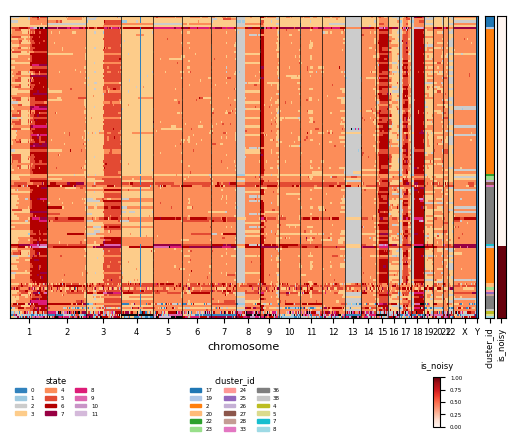

In [14]:
perc_99 = np.nanquantile(adata[(adata.obs['mean_ploidy'] > 3)].layers['copy'], .99)
# g = pl.plot_cell_cn_matrix_fig(adata[adata.obs['mean_ploidy'] > 3], layer_name='copy', cell_order_fields=['is_noisy', 'cluster_id'], annotation_fields=['cluster_id', 'is_noisy'], raw=True, vmax=perc_99)
g = pl.plot_cell_cn_matrix_fig(adata[adata.obs['mean_ploidy'] > 3], layer_name='state', cell_order_fields=['is_noisy', 'cluster_id'], annotation_fields=['cluster_id', 'is_noisy'])

## SPECTRUM-OV-006

In [17]:
path = "/home/vittorio.zampinetti/data/signals_SPECTRUM-OV-006.h5"
# /home/vittorio.zampinetti/data/signals_SPECTRUM-OV-014.h5
# /home/vittorio.zampinetti/data/signals_SPECTRUM-OV-107.h5
# /home/vittorio.zampinetti/data/SA501X3F.h5ad

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 1314 × 6206
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'column', 'img_col', 'index_i5', 'index_i7', 'is_control', 'library_id', 'primer_i5', 'primer_i7', 'row', 'sample_id', 'sample_type', 'cell_call', 'experimental_condition', 'order', 'is_s_phase', 'is_s_phase_prob', 'quality', 'paired_mapped_reads', 'unmapped_reads', 'estimated_library_size', 'expected', 'fastqscreen_mm10', 'total_reads', 'standard_deviation_insert_size', 'total_properly_paired', 'fastqscreen_nohit', 'overlap_with_all_filters_and_qual', 'fastqscreen_m

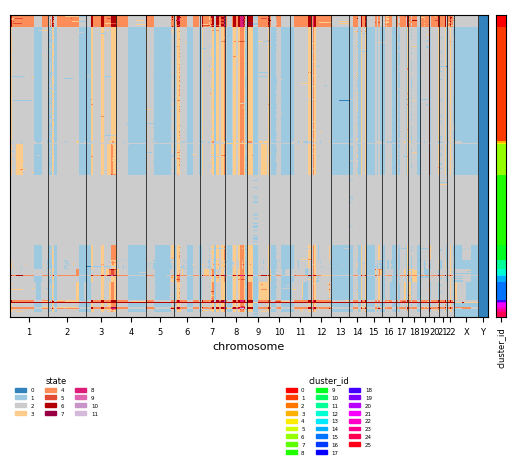

In [18]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

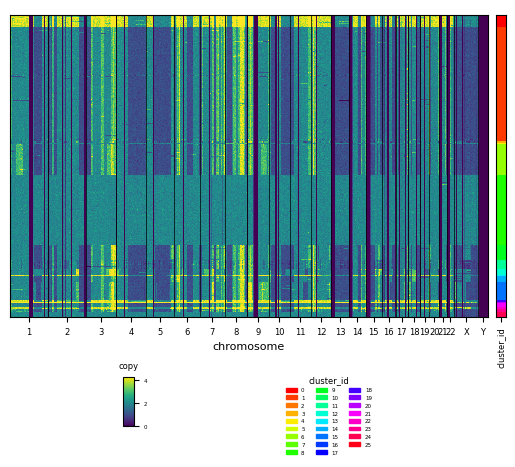

In [19]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'],
                               annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

## SPECTRUM-OV-014

In [20]:
path = "/home/vittorio.zampinetti/data/signals_SPECTRUM-OV-014.h5"
# /home/vittorio.zampinetti/data/signals_SPECTRUM-OV-107.h5
# /home/vittorio.zampinetti/data/SA501X3F.h5ad

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 1105 × 6206
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'column', 'img_col', 'index_i5', 'index_i7', 'is_control', 'library_id', 'primer_i5', 'primer_i7', 'row', 'sample_id', 'sample_type', 'cell_call', 'experimental_condition', 'order', 'is_s_phase', 'is_s_phase_prob', 'quality', 'fastqscreen_mm10', 'coverage_breadth', 'fastqscreen_salmon', 'paired_mapped_reads', 'fastqscreen_salmon_multihit', 'total_reads', 'median_insert_size', 'paired_duplicate_reads', 'overlap_without_dups', 'unmapped_reads', 'fastqscreen_grch37_mult

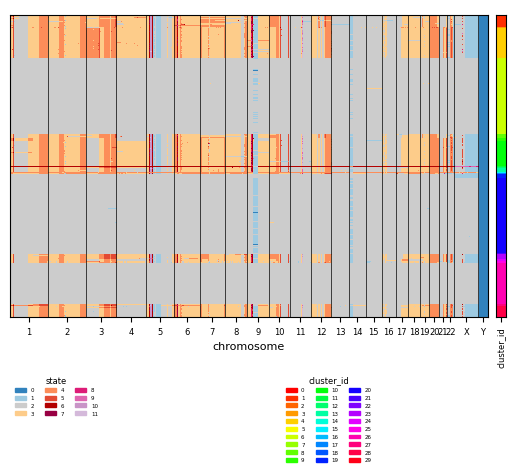

In [21]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

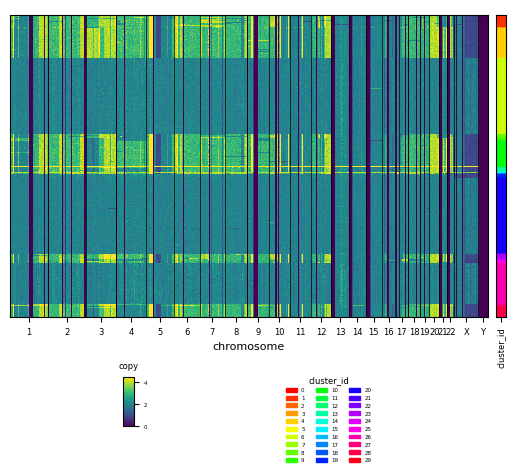

In [22]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'],
                               annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

## SPECTRUM-OV-107

In [23]:
path = "/home/vittorio.zampinetti/data/signals_SPECTRUM-OV-107.h5"
# /home/vittorio.zampinetti/data/SA501X3F.h5ad

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 608 × 6206
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'column', 'img_col', 'index_i5', 'index_i7', 'is_control', 'library_id', 'primer_i5', 'primer_i7', 'row', 'sample_id', 'sample_type', 'cell_call', 'experimental_condition', 'order', 'is_s_phase', 'is_s_phase_prob', 'quality', 'paired_mapped_reads', 'coverage_depth', 'total_reads', 'fastqscreen_nohit', 'standard_deviation_insert_size', 'coverage_breadth', 'fastqscreen_grch37', 'percent_duplicate_reads', 'total_mapped_reads', 'paired_duplicate_reads', 'aligned', 'expect

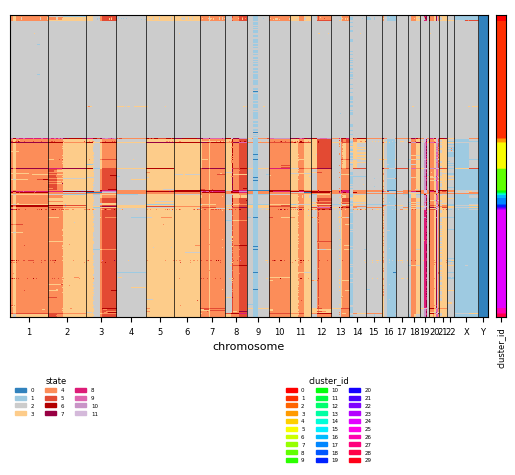

In [24]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

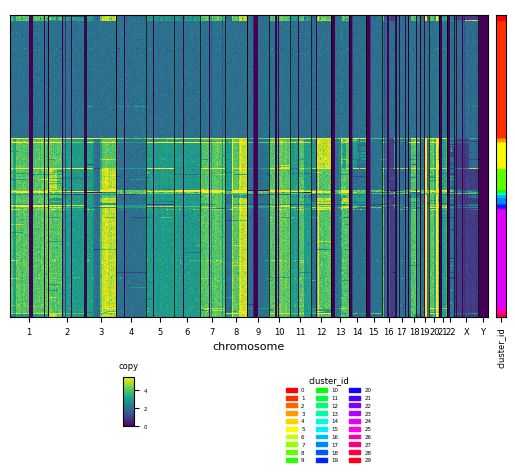

In [25]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'],
                               annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

## P01-066



In [26]:
path = "/home/vittorio.zampinetti/data/P01-066_cn_data.h5ad"
# /home/vittorio.zampinetti/data/SA501X3F.h5ad

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 683 × 6206
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'percent_duplicate_reads', 'standard_deviation_insert_size', 'sample_type', 'overlap_with_all_filters', 'unpaired_duplicate_reads', 'fastqscreen_salmon_multihit', 'index_i5', 'unpaired_mapped_reads', 'fastqscreen_mouse', 'pick_met', 'index_i7', 'mean_insert_size', 'fastqscreen_salmon', 'library_id', 'index_sequence', 'estimated_library_size', 'coverage_depth', 'is_contaminated', 'fastqscreen_mouse_multihit', 'total_reads', 'column', 'total_properly_paired', 'median_in

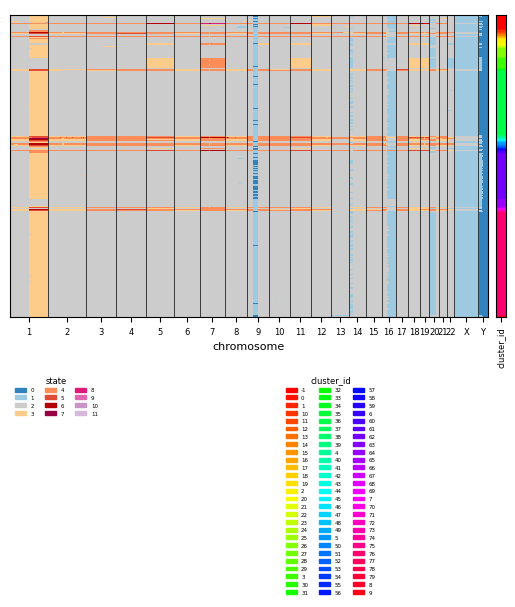

In [27]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

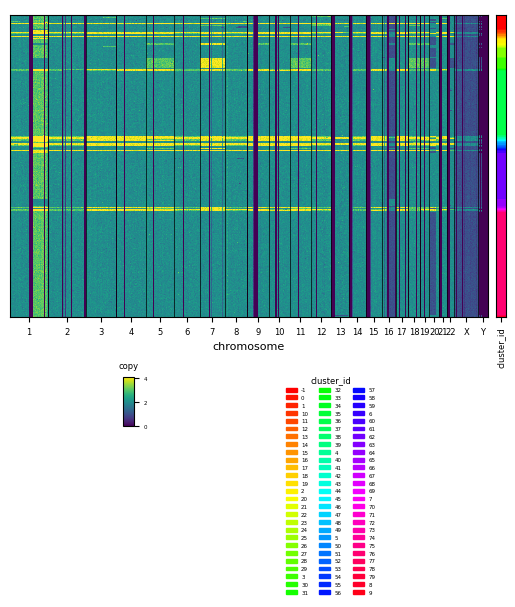

In [28]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'],
                               annotation_fields=['cluster_id'], raw=True, vmax=perc_98)